# Ejercicio 3: Traveling Salesman Problem (TSP)

### Representación como problema de búsqueda

El **Traveling Salesman Problem (TSP)** consiste en hallar la ruta más corta para visitar todas las ciudades de un grafo completo, **exactamente una vez cada una**, y regresar a la ciudad de origen.


---
## 1. Espacio de configuraciones $\Omega$

Una **configuración** es una permutación de las $n$ ciudades que define un ciclo Hamiltoniano.

$$\Omega = \{ \pi = (\pi_1, \pi_2, \ldots, \pi_n) : \pi \text{ es una permutación de las ciudades} \}$$

Si se fija la ciudad inicial para eliminar rotaciones equivalentes y además se considera que una ruta y su inversa representan el mismo ciclo, entonces el número de configuraciones distintas es:

$$|\Omega| = \frac{(n-1)!}{2}$$

### Descripción de configuraciones
Cada estado puede representarse como un vector de permutación $\pi = (\pi_1, \pi_2, \ldots, \pi_n)$ donde cada ciudad aparece exactamente una vez y el recorrido termina regresando a la ciudad inicial.

### Tamaño de $\Omega$

| n  | $|\Omega|$ |
|----|-------------:|
| 4  | 3 |
| 5  | 12 |
| 8  | 2,520 |
| 10 | 181,440 |
| 15 | aproximadamente $4.36 \times 10^{10}$ |
| 20 | aproximadamente $6.08 \times 10^{16}$ |

### Función de costo
La calidad de una ruta se mide con la función:

$$f(\pi) = \sum_{i=1}^{n} d(\pi_i, \pi_{(i+1) \bmod n})$$

donde $d(u,v)$ es la distancia entre las ciudades $u$ y $v$. El objetivo es **minimizar** $f(\pi)$.

---
## 2. Árbol de búsqueda para $n=4$

Para las ciudades $\{A, B, C, D\}$, fijando $A$ como ciudad inicial, el árbol de búsqueda de recorridos ordenados tiene la siguiente estructura:

```
Nivel 0 (raíz):         [A]
                       /  |  \
Nivel 1:           [A,B] [A,C] [A,D]
                   / \    / \    / \
Nivel 2:        [A,B,C][A,B,D] [A,C,B][A,C,D] [A,D,B][A,D,C]
                   |      |       |      |       |       |
Nivel 3:       A,B,C,D,A  A,B,D,C,A  A,C,B,D,A  A,C,D,B,A  A,D,B,C,A  A,D,C,B,A
```

El árbol anterior contiene **6 hojas**, que corresponden a las $(n-1)! = 3! = 6$ permutaciones posibles al fijar la primera ciudad.

Si además se identifica cada recorrido con su ruta inversa, entonces solo quedan **3 ciclos distintos**, en concordancia con la fórmula $|\Omega| = \frac{(n-1)!}{2}$.

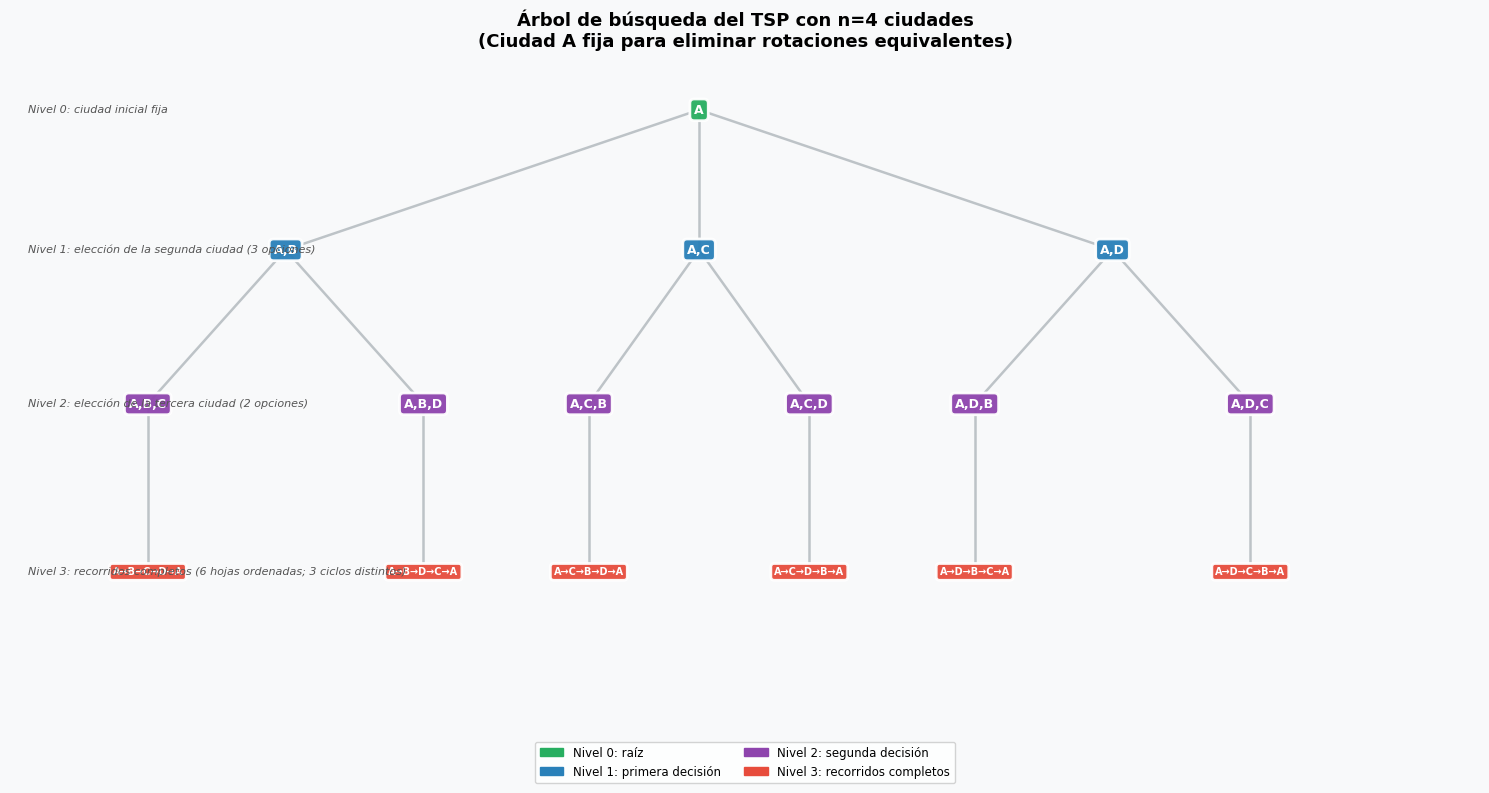

Figura del árbol de búsqueda generada en imagenes.


In [11]:
# ============================================================
# Importaciones y visualización del árbol de búsqueda (n=4)
# ============================================================
import itertools
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

random.seed(42)
np.random.seed(42)

IMAGES_DIR = Path('imagenes')
IMAGES_DIR.mkdir(exist_ok=True)

def draw_search_tree():
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(-0.5, 9.5)
    ax.axis('off')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')

    nodes = {
        'root': ('A', 7, 8.8, 0),
        'AB': ('A,B', 2.5, 6.8, 1),
        'AC': ('A,C', 7, 6.8, 1),
        'AD': ('A,D', 11.5, 6.8, 1),
        'ABC': ('A,B,C', 1, 4.6, 2),
        'ABD': ('A,B,D', 4, 4.6, 2),
        'ACB': ('A,C,B', 5.8, 4.6, 2),
        'ACD': ('A,C,D', 8.2, 4.6, 2),
        'ADB': ('A,D,B', 10, 4.6, 2),
        'ADC': ('A,D,C', 13, 4.6, 2),
        'ABCD': ('A→B→C→D→A', 1, 2.2, 3),
        'ABDC': ('A→B→D→C→A', 4, 2.2, 3),
        'ACBD': ('A→C→B→D→A', 5.8, 2.2, 3),
        'ACDB': ('A→C→D→B→A', 8.2, 2.2, 3),
        'ADBC': ('A→D→B→C→A', 10, 2.2, 3),
        'ADCB': ('A→D→C→B→A', 13, 2.2, 3),
    }

    edges = [
        ('root', 'AB'), ('root', 'AC'), ('root', 'AD'),
        ('AB', 'ABC'), ('AB', 'ABD'),
        ('AC', 'ACB'), ('AC', 'ACD'),
        ('AD', 'ADB'), ('AD', 'ADC'),
        ('ABC', 'ABCD'), ('ABD', 'ABDC'),
        ('ACB', 'ACBD'), ('ACD', 'ACDB'),
        ('ADB', 'ADBC'), ('ADC', 'ADCB'),
    ]

    colors = {0: '#27ae60', 1: '#2980b9', 2: '#8e44ad', 3: '#e74c3c'}

    for u, v in edges:
        x1, y1 = nodes[u][1], nodes[u][2]
        x2, y2 = nodes[v][1], nodes[v][2]
        ax.plot([x1, x2], [y1, y2], color='#bdc3c7', lw=1.8, zorder=1)

    for _, (label, x, y, level) in nodes.items():
        fontsize = 9 if level < 3 else 7
        bbox = dict(
            boxstyle='round,pad=0.35',
            facecolor=colors[level],
            edgecolor='white',
            linewidth=2,
            alpha=0.95,
        )
        ax.text(
            x, y, label, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', bbox=bbox, zorder=2
        )

    level_info = [
        (8.8, 'Nivel 0: ciudad inicial fija'),
        (6.8, 'Nivel 1: elección de la segunda ciudad (3 opciones)'),
        (4.6, 'Nivel 2: elección de la tercera ciudad (2 opciones)'),
        (2.2, 'Nivel 3: recorridos completos (6 hojas ordenadas; 3 ciclos distintos)'),
    ]
    for y_pos, text in level_info:
        ax.text(-0.3, y_pos, text, fontsize=8, color='#555', va='center', style='italic')

    ax.set_title(
        'Árbol de búsqueda del TSP con n=4 ciudades\n'
        '(Ciudad A fija para eliminar rotaciones equivalentes)',
        fontsize=13, fontweight='bold', pad=10
    )

    legend_elements = [
        mpatches.Patch(color='#27ae60', label='Nivel 0: raíz'),
        mpatches.Patch(color='#2980b9', label='Nivel 1: primera decisión'),
        mpatches.Patch(color='#8e44ad', label='Nivel 2: segunda decisión'),
        mpatches.Patch(color='#e74c3c', label='Nivel 3: recorridos completos'),
    ]
    ax.legend(
        handles=legend_elements, loc='lower center', fontsize=8.5,
        ncol=2, framealpha=0.85, bbox_to_anchor=(0.5, -0.04)
    )

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'tsp_search_tree.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura del árbol de búsqueda generada en {IMAGES_DIR}.')

draw_search_tree()

---
## 3. Definición del problema: 8 ciudades de Guatemala

Número de ciudades: 8
Tamaño del espacio |Ω|: (8-1)!/2 = 2,520

Ciudad                    X      Y
------------------------------------
Guatemala                 0      0
Antigua                   3      4
Escuintla                 2     -3
Chimaltenango            -2      3
Cobán                     1      8
Quetzaltenango           -5      2
Huehuetenango            -7      6
Puerto Barrios            9      5


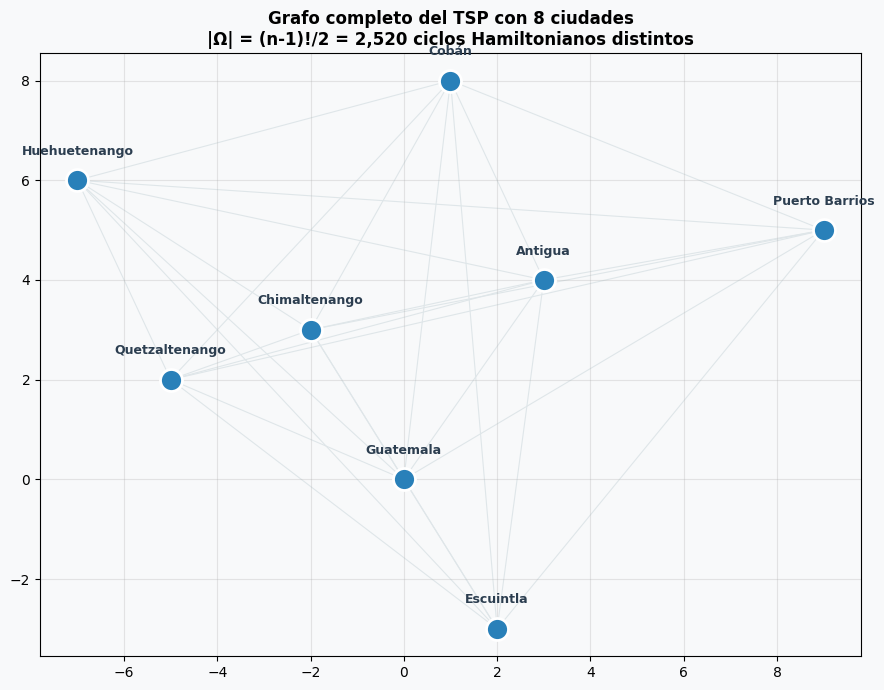

In [12]:
# ============================================================
# Definición del grafo de ciudades y matriz de distancias
# ============================================================
cities = {
    0: ('Guatemala', 0, 0),
    1: ('Antigua', 3, 4),
    2: ('Escuintla', 2, -3),
    3: ('Chimaltenango', -2, 3),
    4: ('Cobán', 1, 8),
    5: ('Quetzaltenango', -5, 2),
    6: ('Huehuetenango', -7, 6),
    7: ('Puerto Barrios', 9, 5),
}

n_cities = len(cities)
city_names = [cities[i][0] for i in range(n_cities)]
coords = np.array([(cities[i][1], cities[i][2]) for i in range(n_cities)], dtype=float)

dist_matrix = np.zeros((n_cities, n_cities))
for i in range(n_cities):
    for j in range(n_cities):
        if i != j:
            dist_matrix[i][j] = round(np.linalg.norm(coords[i] - coords[j]), 4)

omega_size = math.factorial(n_cities - 1) // 2

print(f'Número de ciudades: {n_cities}')
print(f'Tamaño del espacio |Ω|: (8-1)!/2 = {omega_size:,}')
print()
print(f"{'Ciudad':20} {'X':>6} {'Y':>6}")
print('-' * 36)
for _, (name, x, y) in cities.items():
    print(f'{name:20} {x:>6} {y:>6}')

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

for i in range(n_cities):
    for j in range(i + 1, n_cities):
        ax.plot(
            [coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
            color='#dfe6e9', lw=0.8, zorder=1
        )

for i, (x, y) in enumerate(coords):
    ax.scatter(x, y, s=250, color='#2980b9', zorder=3, edgecolors='white', linewidths=2)
    ax.text(
        x, y + 0.45, city_names[i], ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#2c3e50', zorder=4
    )

ax.set_title(
    f'Grafo completo del TSP con {n_cities} ciudades\n'
    f'|Ω| = (n-1)!/2 = {omega_size:,} ciclos Hamiltonianos distintos',
    fontsize=12, fontweight='bold',
 )
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'tsp_full_graph.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Funciones auxiliares

In [13]:
# ============================================================
# Funciones utilitarias compartidas
# ============================================================
def route_cost(route, D):
    """Costo total del ciclo."""
    n = len(route)
    return round(sum(D[route[i]][route[(i + 1) % n]] for i in range(n)), 4)

def canonical_cycle(route, start=0):
    """Representación canónica de un ciclo con una ciudad inicial fija."""
    route = list(route)
    idx = route.index(start)
    forward = route[idx:] + route[:idx]
    reverse = [forward[0]] + list(reversed(forward[1:]))
    return forward if tuple(forward[1:]) <= tuple(reverse[1:]) else reverse

def format_cycle(route, names):
    return ' → '.join(names[c] for c in route) + f' → {names[route[0]]}'

def plot_route(route, D, coords, names, title, ax=None, color='#e74c3c', save_path=None):
    """Dibuja una ruta TSP sobre el grafo de ciudades."""
    route = canonical_cycle(route, start=0)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 7))
        fig.patch.set_facecolor('#f8f9fa')
    else:
        fig = ax.figure

    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            ax.plot(
                [coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                color='#ecf0f1', lw=0.7, zorder=1
            )

    n = len(route)
    for i in range(n):
        a, b = route[i], route[(i + 1) % n]
        ax.annotate(
            '',
            xy=(coords[b, 0], coords[b, 1]),
            xytext=(coords[a, 0], coords[a, 1]),
            arrowprops=dict(arrowstyle='->', color=color, lw=2.5),
            zorder=3,
        )

    for i, (x, y) in enumerate(coords):
        node_color = '#27ae60' if i == route[0] else '#3498db'
        ax.scatter(x, y, s=220, color=node_color, zorder=4, edgecolors='white', linewidths=1.5)
        ax.text(
            x, y + 0.42, names[i], ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#2c3e50', zorder=5
        )

    cost = route_cost(route, D)
    ax.set_title(f'{title}\nCosto: {cost:.4f}', fontsize=10, fontweight='bold')
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, alpha=0.25)

    if standalone:
        plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    if standalone:
        plt.show()

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


---
## 5. Algoritmo 1: fuerza bruta

El método exacto evalúa todas las configuraciones canónicas de $\Omega$, es decir, fija la ciudad inicial y descarta recorridos que solo difieren por inversión. Su complejidad sigue siendo factorial.

Ejecutando búsqueda exhaustiva sobre configuraciones canónicas.

Fuerza bruta: solución óptima global
Ruta: Guatemala → Escuintla → Puerto Barrios → Antigua → Cobán → Huehuetenango → Quetzaltenango → Chimaltenango → Guatemala
Costo: 44.2768
Rutas evaluadas: 2,520 (= (n-1)!/2)
Tiempo: 0.0164 s


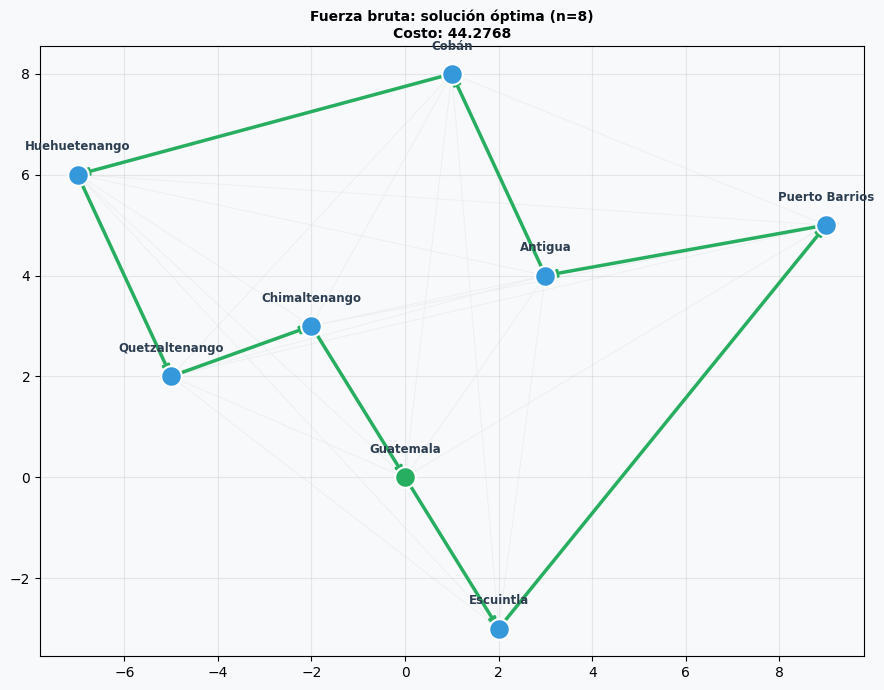

In [14]:
# ============================================================
# Fuerza bruta: evaluación exhaustiva de rutas canónicas
# ============================================================
def brute_force_tsp(D, start=0):
    n = D.shape[0]
    others = [i for i in range(n) if i != start]
    best_cost = float('inf')
    best_route = None
    total = 0

    for perm in itertools.permutations(others):
        if perm[0] > perm[-1]:
            continue
        route = [start] + list(perm)
        cost = route_cost(route, D)
        total += 1
        if cost < best_cost:
            best_cost = cost
            best_route = route

    return canonical_cycle(best_route, start=start), best_cost, total

print('Ejecutando búsqueda exhaustiva sobre configuraciones canónicas.')
t0 = time.time()
bf_route, bf_cost, bf_total = brute_force_tsp(dist_matrix)
bf_time = time.time() - t0

print()
print('Fuerza bruta: solución óptima global')
print(f'Ruta: {format_cycle(bf_route, city_names)}')
print(f'Costo: {bf_cost:.4f}')
print(f'Rutas evaluadas: {bf_total:,} (= (n-1)!/2)')
print(f'Tiempo: {bf_time:.4f} s')

plot_route(
    bf_route, dist_matrix, coords, city_names,
    f'Fuerza bruta: solución óptima (n={n_cities})',
    color='#27ae60',
    save_path=IMAGES_DIR / 'tsp_brute_force.png',
)

---
## 6. Algoritmo 2: heurística Nearest Neighbor

Esta heurística constructiva selecciona siempre la ciudad no visitada más cercana. Su complejidad es $O(n^2)$ y no garantiza la solución óptima.

Nearest Neighbor
Ruta: Guatemala → Escuintla → Puerto Barrios → Antigua → Cobán → Huehuetenango → Quetzaltenango → Chimaltenango → Guatemala
Costo: 44.2768
Diferencia relativa respecto al óptimo: 0.00%


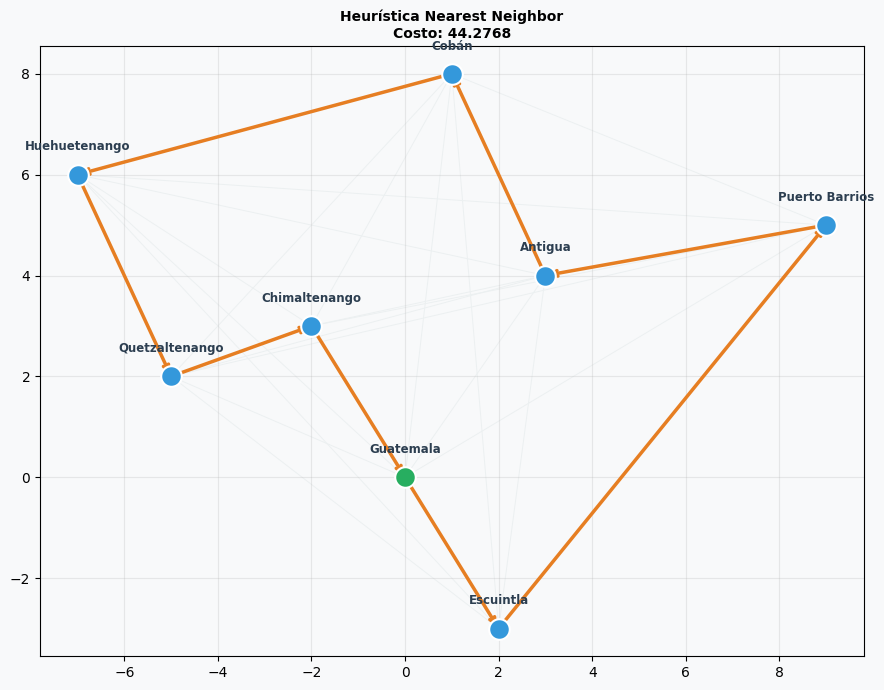

In [15]:
# ============================================================
# Heurística Nearest Neighbor
# ============================================================
def nearest_neighbor_tsp(D, start=0):
    n = D.shape[0]
    visited = [False] * n
    route = [start]
    visited[start] = True

    for _ in range(n - 1):
        current = route[-1]
        best_distance, best_city = float('inf'), None
        for j in range(n):
            if not visited[j] and D[current][j] < best_distance:
                best_distance, best_city = D[current][j], j
        route.append(best_city)
        visited[best_city] = True

    route = canonical_cycle(route, start=0)
    return route, route_cost(route, D)

best_nn_route, best_nn_cost = None, float('inf')
for start_city in range(n_cities):
    candidate_route, candidate_cost = nearest_neighbor_tsp(dist_matrix, start_city)
    if candidate_cost < best_nn_cost:
        best_nn_route, best_nn_cost = candidate_route, candidate_cost

gap_nn = (best_nn_cost - bf_cost) / bf_cost * 100
print('Nearest Neighbor')
print(f'Ruta: {format_cycle(best_nn_route, city_names)}')
print(f'Costo: {best_nn_cost:.4f}')
print(f'Diferencia relativa respecto al óptimo: {gap_nn:.2f}%')

plot_route(
    best_nn_route, dist_matrix, coords, city_names,
    'Heurística Nearest Neighbor',
    color='#e67e22',
    save_path=IMAGES_DIR / 'tsp_nearest_neighbor.png',
)

---
## 7. Algoritmo 3: mejora local 2-opt

La mejora local **2-opt** intenta reducir el costo invirtiendo segmentos de la ruta hasta alcanzar un mínimo local.

2-opt a partir de la ruta de Nearest Neighbor
Ruta: Guatemala → Escuintla → Puerto Barrios → Antigua → Cobán → Huehuetenango → Quetzaltenango → Chimaltenango → Guatemala
Costo: 44.2768
Iteraciones de 2-opt: 1
Diferencia relativa respecto al óptimo: 0.00%


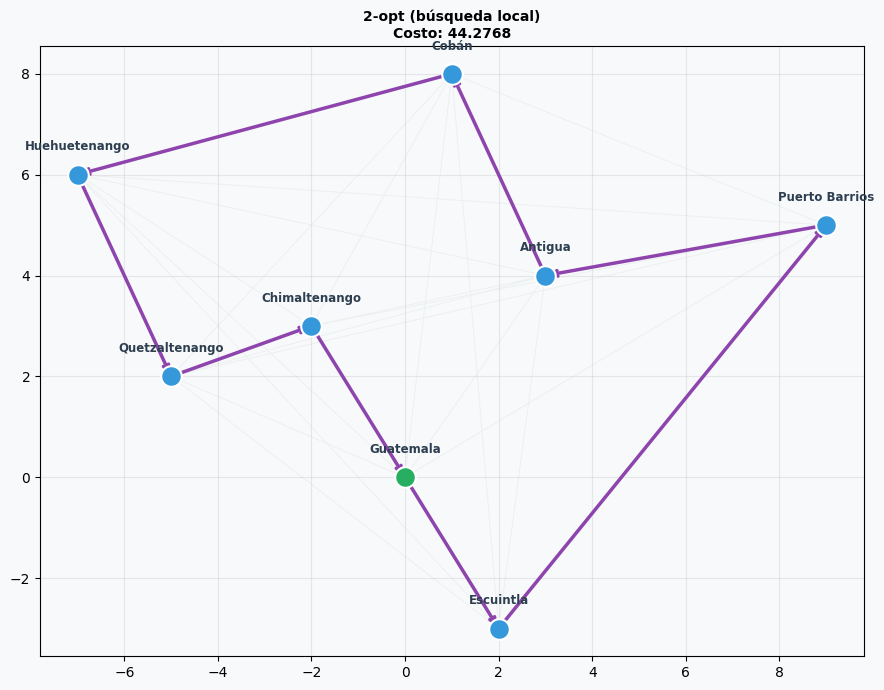

In [16]:
# ============================================================
# Mejora local 2-opt
# ============================================================
def two_opt(route, D):
    best = list(route)
    best_cost = route_cost(best, D)
    improved = True
    iterations = 0

    while improved:
        improved = False
        for i in range(1, len(best) - 1):
            for j in range(i + 1, len(best)):
                new_route = best[:i] + best[i:j + 1][::-1] + best[j + 1:]
                new_cost = route_cost(new_route, D)
                if new_cost < best_cost - 1e-10:
                    best, best_cost = new_route, new_cost
                    improved = True
        iterations += 1

    best = canonical_cycle(best, start=0)
    return best, best_cost, iterations

two_opt_route, two_opt_cost, two_opt_iters = two_opt(best_nn_route, dist_matrix)
gap_2opt = (two_opt_cost - bf_cost) / bf_cost * 100

print('2-opt a partir de la ruta de Nearest Neighbor')
print(f'Ruta: {format_cycle(two_opt_route, city_names)}')
print(f'Costo: {two_opt_cost:.4f}')
print(f'Iteraciones de 2-opt: {two_opt_iters}')
print(f'Diferencia relativa respecto al óptimo: {gap_2opt:.2f}%')

plot_route(
    two_opt_route, dist_matrix, coords, city_names,
    '2-opt (búsqueda local)',
    color='#8e44ad',
    save_path=IMAGES_DIR / 'tsp_two_opt.png',
)

---
## 8. Algoritmo 4: algoritmo genético

Esta metaheurística mantiene una población de rutas y aplica selección, cruzamiento, mutación y elitismo para aproximarse al óptimo.

Ejecutando algoritmo genético con 600 generaciones.

Algoritmo genético
Ruta: Guatemala → Escuintla → Puerto Barrios → Antigua → Cobán → Huehuetenango → Quetzaltenango → Chimaltenango → Guatemala
Costo: 44.2768
Diferencia relativa respecto al óptimo: 0.00%
Tiempo: 1.4087 s


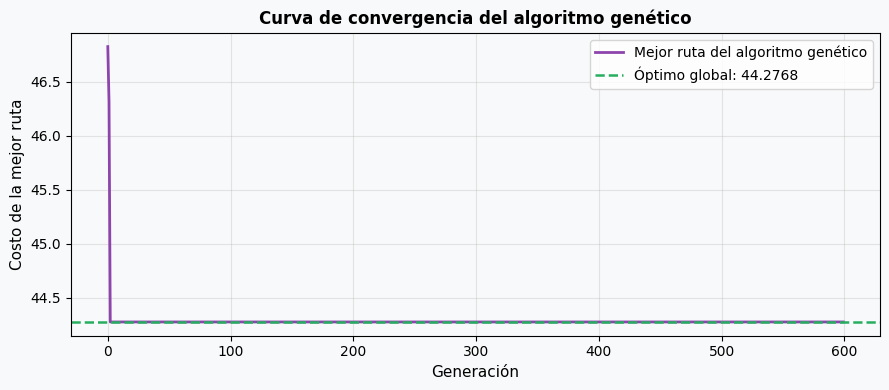

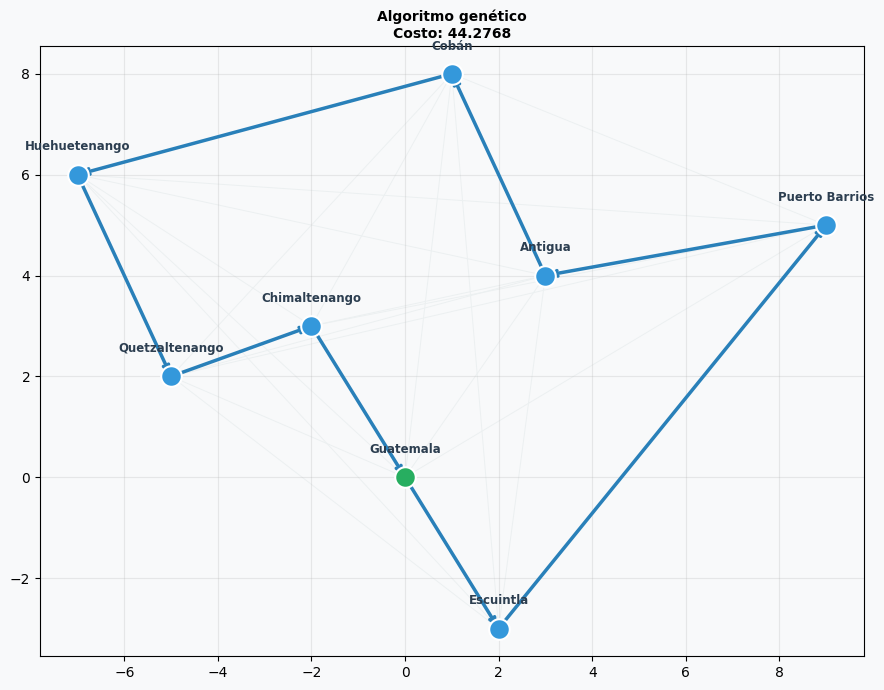

In [17]:
# ============================================================
# Algoritmo genético para TSP
# ============================================================
class GeneticTSP:
    def __init__(self, D, pop_size=150, n_gen=600, mut_rate=0.03, elite=25):
        self.D = D
        self.n = D.shape[0]
        self.pop_size = pop_size
        self.n_gen = n_gen
        self.mut_rate = mut_rate
        self.elite = elite
        self.history = []

    def _init_pop(self):
        base = list(range(self.n))
        population = []
        for _ in range(self.pop_size):
            route = base.copy()
            random.shuffle(route)
            population.append(route)
        return population

    def _select(self, population):
        ranking = sorted(range(len(population)), key=lambda i: route_cost(population[i], self.D))
        n = len(ranking)
        probs = np.array([2 * (n - k) / (n * (n + 1)) for k in range(n)])
        selected_idx = np.random.choice(ranking, size=self.pop_size, p=probs)
        return [population[i] for i in selected_idx]

    def _ox(self, parent1, parent2):
        n = len(parent1)
        a, b = sorted(random.sample(range(n), 2))
        child = [-1] * n
        child[a:b + 1] = parent1[a:b + 1]
        pos = (b + 1) % n
        for gene in parent2[b + 1:] + parent2[:b + 1]:
            if gene not in child:
                child[pos] = gene
                pos = (pos + 1) % n
        return child

    def _mutate(self, route):
        route = route.copy()
        if random.random() < self.mut_rate:
            i, j = random.sample(range(len(route)), 2)
            route[i], route[j] = route[j], route[i]
        return route

    def run(self):
        population = self._init_pop()
        for _ in range(self.n_gen):
            ranked = sorted(population, key=lambda route: route_cost(route, self.D))
            self.history.append(route_cost(ranked[0], self.D))
            next_population = ranked[:self.elite]
            selected = self._select(population)
            while len(next_population) < self.pop_size:
                parent1, parent2 = random.sample(selected[:60], 2)
                child = self._ox(parent1, parent2)
                next_population.append(self._mutate(child))
            population = next_population

        best = min(population, key=lambda route: route_cost(route, self.D))
        best = canonical_cycle(best, start=0)
        return best, route_cost(best, self.D)

print('Ejecutando algoritmo genético con 600 generaciones.')
t0 = time.time()
ga = GeneticTSP(dist_matrix)
ga_route, ga_cost = ga.run()
ga_time = time.time() - t0
gap_ga = (ga_cost - bf_cost) / bf_cost * 100

print()
print('Algoritmo genético')
print(f'Ruta: {format_cycle(ga_route, city_names)}')
print(f'Costo: {ga_cost:.4f}')
print(f'Diferencia relativa respecto al óptimo: {gap_ga:.2f}%')
print(f'Tiempo: {ga_time:.4f} s')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ga.history, color='#8e44ad', lw=2, label='Mejor ruta del algoritmo genético')
ax.axhline(y=bf_cost, color='#27ae60', lw=1.8, linestyle='--', label=f'Óptimo global: {bf_cost:.4f}')
ax.set_xlabel('Generación', fontsize=11)
ax.set_ylabel('Costo de la mejor ruta', fontsize=11)
ax.set_title('Curva de convergencia del algoritmo genético', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'ga_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

plot_route(
    ga_route, dist_matrix, coords, city_names,
    'Algoritmo genético',
    color='#2980b9',
    save_path=IMAGES_DIR / 'tsp_genetic.png',
)

---
## 9. Comparación visual de los métodos

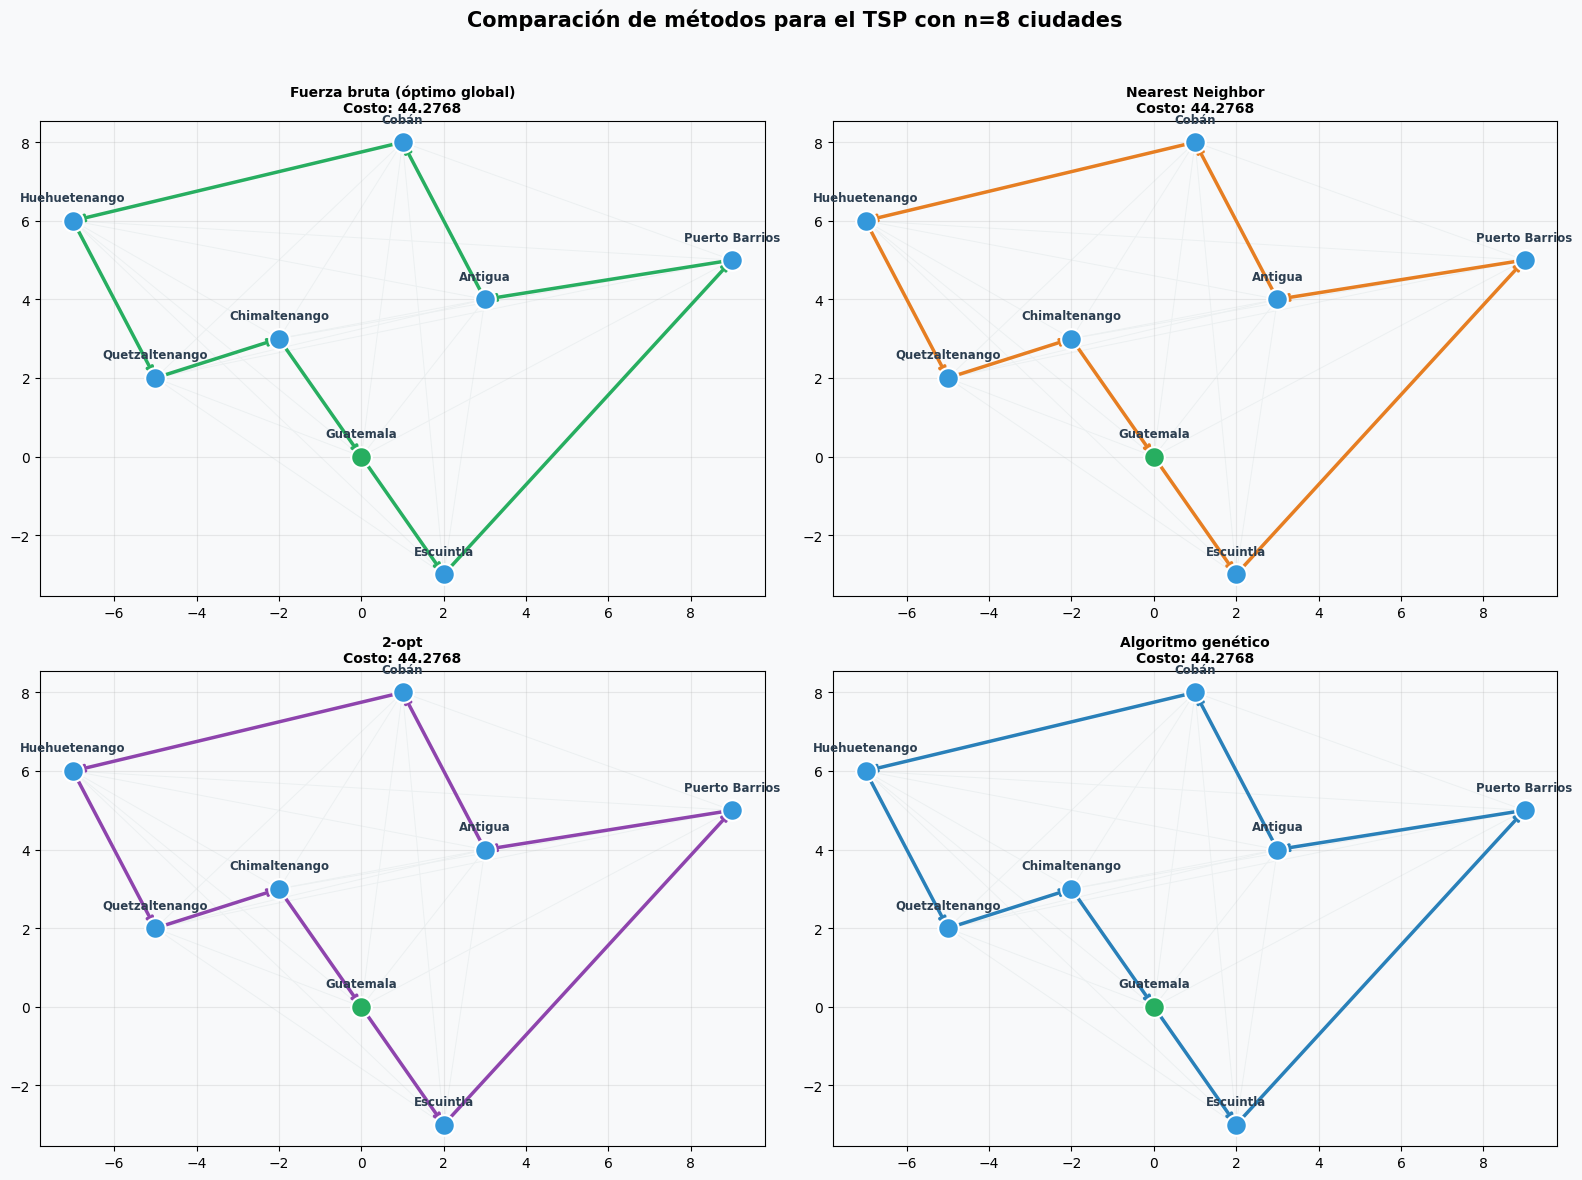


                        RESUMEN COMPARATIVO                         
Método                                    Costo      Dif. relativa
--------------------------------------------------------------------
Fuerza bruta (óptimo exacto)            44.2768              0.00% (óptimo)
Nearest Neighbor                        44.2768              0.00% (óptimo)
Nearest Neighbor + 2-opt                44.2768              0.00% (óptimo)
Algoritmo genético                      44.2768              0.00% (óptimo)


In [18]:
# ============================================================
# Comparación visual de rutas y tabla de resultados
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Comparación de métodos para el TSP con n={n_cities} ciudades', fontsize=15, fontweight='bold')
fig.patch.set_facecolor('#f8f9fa')

methods = [
    (bf_route, '#27ae60', 'Fuerza bruta (óptimo global)'),
    (best_nn_route, '#e67e22', 'Nearest Neighbor'),
    (two_opt_route, '#8e44ad', '2-opt'),
    (ga_route, '#2980b9', 'Algoritmo genético'),
]

for ax, (route, color, title) in zip(axes.flatten(), methods):
    plot_route(route, dist_matrix, coords, city_names, title, ax=ax, color=color)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(IMAGES_DIR / 'tsp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 68)
print(f"{'RESUMEN COMPARATIVO':^68}")
print('=' * 68)
print(f"{'Método':<34} {'Costo':>12} {'Dif. relativa':>18}")
print('-' * 68)
results = [
    ('Fuerza bruta (óptimo exacto)', bf_cost, 0.0),
    ('Nearest Neighbor', best_nn_cost, (best_nn_cost - bf_cost) / bf_cost * 100),
    ('Nearest Neighbor + 2-opt', two_opt_cost, (two_opt_cost - bf_cost) / bf_cost * 100),
    ('Algoritmo genético', ga_cost, (ga_cost - bf_cost) / bf_cost * 100),
]
for name, cost, gap in results:
    suffix = ' (óptimo)' if abs(gap) < 1e-12 else ''
    print(f'{name:<34} {cost:>12.4f} {gap:>17.2f}%{suffix}')
print('=' * 68)

---
## 10. Análisis de complejidad del espacio de búsqueda

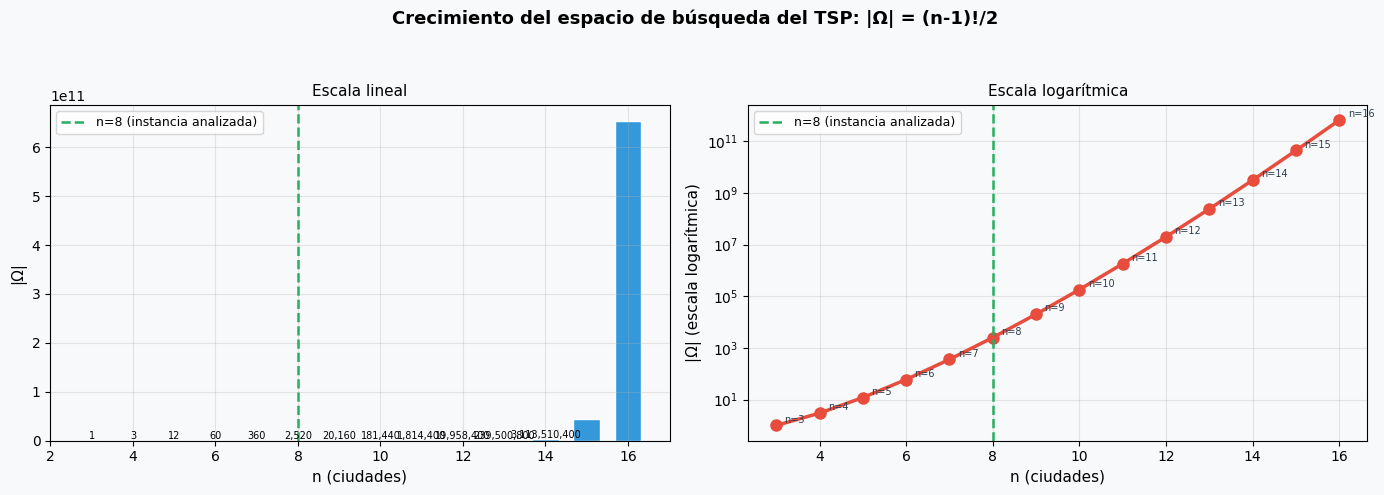


    n            |Ω| = (n-1)!/2
-----------------------------------
    3                         1
    4                         3
    5                        12
    6                        60
    7                       360
    8                     2,520  instancia analizada
    9                    20,160
   10                   181,440
   11                 1,814,400
   12                19,958,400
   13               239,500,800
   14             3,113,510,400
   15            43,589,145,600
   16           653,837,184,000
   17        10,461,394,944,000
   18       177,843,714,048,000
   19     3,201,186,852,864,000
   20    60,822,550,204,416,000


In [19]:
# ============================================================
# Crecimiento de |Ω| respecto a n
# ============================================================
ns = list(range(3, 17))
sizes = [math.factorial(n - 1) // 2 for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crecimiento del espacio de búsqueda del TSP: |Ω| = (n-1)!/2', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#f8f9fa')

axes[0].bar(ns, sizes, color='#3498db', edgecolor='white', width=0.65)
axes[0].set_xlabel('n (ciudades)', fontsize=11)
axes[0].set_ylabel('|Ω|', fontsize=11)
axes[0].set_title('Escala lineal', fontsize=11)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(True, alpha=0.3)
for x, y in zip(ns, sizes):
    if y < max(sizes) * 0.02:
        axes[0].text(x, y + max(sizes) * 0.005, f'{y:,}', ha='center', fontsize=7)

axes[1].semilogy(ns, sizes, 'o-', color='#e74c3c', lw=2.5, markersize=8)
axes[1].set_xlabel('n (ciudades)', fontsize=11)
axes[1].set_ylabel('|Ω| (escala logarítmica)', fontsize=11)
axes[1].set_title('Escala logarítmica', fontsize=11)
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(True, alpha=0.3, which='both')
for x, y in zip(ns, sizes):
    axes[1].annotate(f'n={x}', (x, y), textcoords='offset points', xytext=(6, 2), fontsize=7, color='#2c3e50')

for ax in axes:
    ax.axvline(x=n_cities, color='#27ae60', linestyle='--', lw=1.8, label=f'n={n_cities} (instancia analizada)')
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(IMAGES_DIR / 'tsp_search_space.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(f"{'n':>5} {'|Ω| = (n-1)!/2':>25}")
print('-' * 35)
for n_val in range(3, 21):
    size = math.factorial(n_val - 1) // 2
    mark = '  instancia analizada' if n_val == n_cities else ''
    print(f'{n_val:>5} {size:>25,}{mark}')

---
## 11. Conclusiones

| Componente | Descripción |
|---|---|
| **Espacio $\Omega$** | Todos los ciclos Hamiltonianos sobre $n$ ciudades |
| **Tamaño $|\Omega|$** | $\frac{(n-1)!}{2}$ cuando se fija la ciudad inicial y se identifica una ruta con su inversa |
| **Descripción** | Vectores de permutación $\pi = (\pi_1, \ldots, \pi_n)$ |
| **Función de costo** | $f(\pi) = \sum_{i=1}^{n} d(\pi_i, \pi_{(i+1) \bmod n})$ |

### Comparación de algoritmos

| Algoritmo | Optimalidad | Complejidad | Escalabilidad |
|---|---|---|---|
| Fuerza bruta | Óptimo exacto | $O(n!)$ | Solo viable para instancias pequeñas |
| Nearest Neighbor | Heurístico | $O(n^2)$ | Alta |
| 2-opt | Mínimo local | Depende del número de mejoras; cada barrido es $O(n^2)$ | Buena |
| Algoritmo genético | Aproximado | $O(g · p · n)$ | Alta |

La principal conclusión es que el TSP presenta un crecimiento factorial del espacio de búsqueda, por lo que los métodos exactos se vuelven rápidamente inviables. En consecuencia, para instancias medianas o grandes se recurre a heurísticas y metaheurísticas capaces de obtener soluciones de buena calidad en tiempos razonables.